# Cholor Fringing Calculation

This notebook demonstrates basic usage of the core functions in `scr.chromf.cfw`.

In [13]:
# ───────────────────────────── Imports ─────────────────────────────
import sys
from pathlib import Path
from typing import Literal

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, interact_manual, FloatSlider

# Allow "import chromf …" without installing the package
sys.path.insert(0, str(Path("..").resolve() / "src"))

from chromf.spectrum_loader import _load_defocus, _load_daylight, _load_sensor, channel_products
from chromf.optiland_bridge import (
    compute_chl_curve,
    compute_rori_chl_curve,
    compute_rori_spot_curves,
    compute_polychromatic_esf,
)
from chromf.cfw import (
    edge_rgb_response,
    detect_fringe_binary,
    fringe_width,
)
from optiland import fileio,optic
from optiland.physical_apertures import RadialAperture

FNO 1 = 2.0，focal length 1 = 85.00003717952896 mm


(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

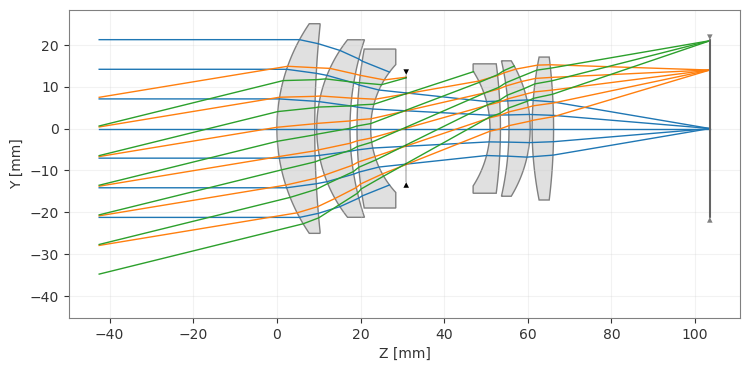

In [35]:
lens1 = fileio.load_zemax_file("C:\\Users\\meetf\\Downloads\\NikonAINikkor85mmf2S.zmx")
clear_semi_diameters = [
            None, 25.062, 24.642, 21.225, 21.225, 19.006, 15.289,
            12.836, 13.730, 15.469, 16.188, 16.188, 17.088, 17.088, 21.190
        ]
for i, r in enumerate(clear_semi_diameters):
            if r is not None:
                lens1.surface_group.surfaces[i].aperture = RadialAperture(r_max=r)
print(f"FNO 1 = {lens1.paraxial.FNO()}，focal length 1 = {lens1.paraxial.f2()} mm")
lens1.draw(num_rays=7)


In [36]:
# ──────────────────────────── Data load ────────────────────────────
prods = channel_products()
sensor_wl = prods["blue"][:, 0]   # nm — must match SENSOR_RESPONSE in cfw.py

if lens1 is not None:
    paraxial_curve              = compute_chl_curve(lens1, wavelengths_nm=sensor_wl)
    rori_curve, spot_curve      = compute_rori_spot_curves(lens1, wavelengths_nm=sensor_wl)
    focal_shift_curve           = rori_curve          # ← RoRi used for fringe calculations
    FN_DEFAULT                  = float(lens1.paraxial.FNO())

else:
    paraxial_curve    = _load_defocus()
    rori_curve        = paraxial_curve
    spot_curve        = np.column_stack((paraxial_curve[:, 0],
                                         np.zeros(len(paraxial_curve))))
    focal_shift_curve = paraxial_curve
    FN_DEFAULT        = 1.8

wl      = focal_shift_curve[:, 0]
chl_um  = focal_shift_curve[:, 1]               # RoRi CHL in µm

sensor_map = {"R": prods["red"][:, 1],
              "G": prods["green"][:, 1],
              "B": prods["blue"][:, 1]}

print(f"spot_curve rho_sa range: "
      f"{spot_curve[:, 1].min():.1f} – {spot_curve[:, 1].max():.1f} µm  "
      f"(mean {spot_curve[:, 1].mean():.1f} µm)")

spot_curve rho_sa range: 11.8 – 18.4 µm  (mean 16.8 µm)


In [49]:
# ──────────────────────────── Display constants ─────────────────────
GAMMA_DEFAULT    = 2.2        # display gamma
EXPOSURE_DEFAULT = 1.0        # tanh-curve slope
XRANGE           = 200         # half-width of x-scan window (µm)
DEFOCUS_RANGE    = 700        # ±z sweep (µm)
DEFOCUS_STEP     = 5          # slider step (µm)
X_RES_P1   = 1              # Plot 1 sampling step (µm)
X_RES_P2   = 1              # Plot 2 sampling step (µm)
IMG_HEIGHT = 60               # Plot 2 image height (px)

# Colour-fringe detection threshold — pixel is "fringed" when any pair of
# R/G/B channel responses differs by more than this value (0–1 scale).
COLOR_DIFF_THRESHOLD = 0.15

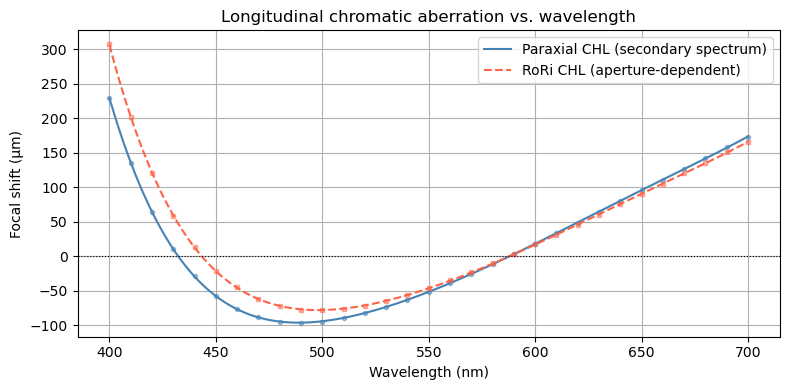

In [44]:
# ───────────────────── Optional diagnostic plots ───────────────────
# --- 1. CHL curve: paraxial vs RoRi (aperture-dependent) -----------
par_wl1  = paraxial_curve[:, 0]
par_chl1 = paraxial_curve[:, 1]
ror_wl1  = rori_curve[:, 0]
ror_chl1 = rori_curve[:, 1]

# 6th-order polynomial fits for smooth curves
wl_fit = np.linspace(par_wl1.min(), par_wl1.max(), 300)
par_fit = np.polyval(np.polyfit(par_wl1, par_chl1, 6), wl_fit)
ror_fit = np.polyval(np.polyfit(ror_wl1, ror_chl1, 6), wl_fit)

plt.figure(figsize=(8, 4))
plt.plot(par_wl1,  par_chl1,  "o",  color="steelblue",  ms=3, alpha=0.5)
plt.plot(wl_fit,  par_fit,  "-",  color="steelblue",  label="Paraxial CHL (secondary spectrum)")
plt.plot(ror_wl1,  ror_chl1,  "s",  color="tomato",     ms=3, alpha=0.5)
plt.plot(wl_fit,  ror_fit,  "--", color="tomato",     label="RoRi CHL (aperture-dependent)")
plt.axhline(0, color="k", lw=0.8, ls=":")
plt.title("Longitudinal chromatic aberration vs. wavelength")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Focal shift (µm)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

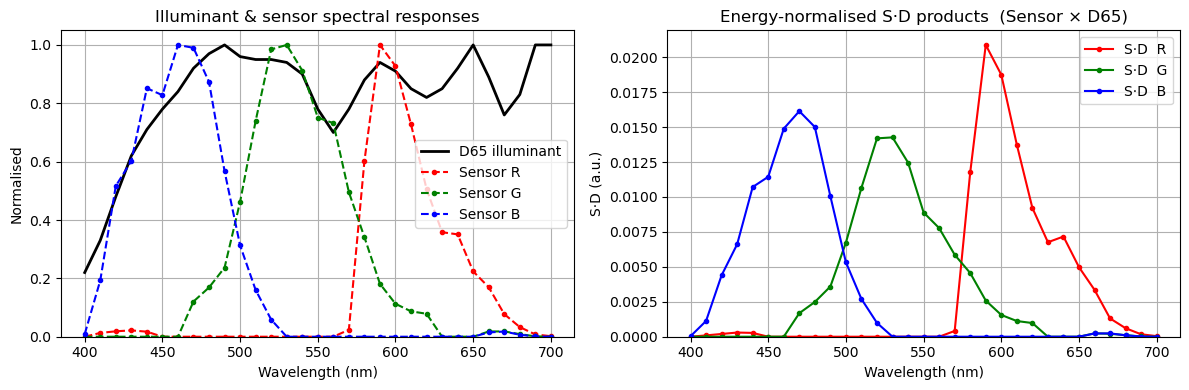

In [6]:
# --- 2. Illuminant, sensor responses, and S·D products -------------
# Load raw curves and normalise each to peak = 1
_raw = {ch: _load_sensor(ch) for ch in ("red", "green", "blue")}
for v in _raw.values():
    v[:, 1] /= v[:, 1].max()

_dl      = _load_daylight()
dl_vals  = np.interp(wl, _dl[:, 0], _dl[:, 1])
dl_vals /= dl_vals.max()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left panel: D65 illuminant + raw sensor responses
ax1.plot(wl, dl_vals, color="k", lw=2, label="D65 illuminant")
for ch, col in (("red", "r"), ("green", "g"), ("blue", "b")):
    ax1.plot(_raw[ch][:, 0], _raw[ch][:, 1], "o--", color=col, ms=3,
             label=f"Sensor {ch[0].upper()}")
ax1.set_title("Illuminant & sensor spectral responses")
ax1.set_xlabel("Wavelength (nm)");  ax1.set_ylabel("Normalised")
ax1.set_ylim(0, None);  ax1.grid(True);  ax1.legend()

# Right panel: energy-normalised S·D products
for ch, col in {"R": "r", "G": "g", "B": "b"}.items():
    ax2.plot(wl, sensor_map[ch], "o-", color=col, ms=3, label=f"S·D  {ch}")
ax2.set_title("Energy-normalised S·D products  (Sensor × D65)")
ax2.set_xlabel("Wavelength (nm)");  ax2.set_ylabel("S·D (a.u.)")
ax2.set_ylim(0, None);  ax2.grid(True);  ax2.legend()

plt.tight_layout();  plt.show()

In [ ]:
# ─────────────────────── Interactive section ───────────────────────

def update_plots(
    z: float,
    gamma: float,
    exposure: float,
    psf_mode_choice: Literal["geom", "gauss"],
    chl_mode: Literal["rori", "paraxial"],
    use_sa: bool,
) -> None:
    psf_mode: Literal["geom", "gauss"] = psf_mode_choice
    chl_curve1 = rori_curve[:, 1] if chl_mode == "rori" else paraxial_curve[:, 1]
    sa_curve1  = spot_curve[:, 1] if (use_sa and chl_mode == "rori") else None

    # ---------- Plot 1: edge functions ----------
    x_vals = np.arange(-XRANGE, XRANGE + X_RES_P1, X_RES_P1, dtype=float)
    edge_rgb = np.array([
        edge_rgb_response(
            x, z,
            exposure_slope=exposure,
            gamma=gamma,
            chl_curve_um=chl_curve1,
            sa_curve_um=sa_curve1,
            f_number=FN_DEFAULT,
            psf_mode=psf_mode,
        )
        for x in x_vals
    ])
    edge_r, edge_g, edge_b = edge_rgb.T

    boundaries = np.array([
        detect_fringe_binary(
            x, z,
            exposure_slope=exposure,
            gamma=gamma,
            chl_curve_um=chl_curve1,
            sa_curve_um=sa_curve1,
            f_number=FN_DEFAULT,
            psf_mode=psf_mode,
            color_diff_threshold=COLOR_DIFF_THRESHOLD,
        )
        for x in x_vals
    ], dtype=bool)

    fig = plt.figure(figsize=(12, 6))
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.plot(x_vals, edge_r, color="r", label="R")
    ax1.plot(x_vals, edge_g, color="g", label="G")
    ax1.plot(x_vals, edge_b, color="b", label="B")
    ax1.axhline(COLOR_DIFF_THRESHOLD, color="k", ls=":", lw=1, alpha=0.5,
                label=f"Threshold = {COLOR_DIFF_THRESHOLD:.2f}")

    jumps = np.flatnonzero(np.diff(boundaries.astype(int), prepend=boundaries[0]))
    if jumps.size:
        for idx in jumps:
            ax1.axvline(x_vals[idx], color="k", ls="--", lw=1,
                        label="Fringe boundary" if idx == jumps[0] else None)

    psf_label = {"geom": "Geometric (pillbox) PSF", "gauss": "Gaussian PSF"}.get(psf_mode, psf_mode)
    chl_label = {"rori": "RoRi (aperture-dependent)", "paraxial": "Paraxial CHL"}.get(chl_mode, chl_mode)
    sa_label  = " + SA" if sa_curve1 is not None else ""
    ax1.set(xlabel="x (µm)", ylabel="Normalised response",
            title=f"Edge responses — {psf_label}  |  {chl_label}{sa_label}",
            ylim=(0, 1))
    ax1.legend();  ax1.grid(True)

    # ---------- Plot 2: pseudo-density map ----------
    X = np.arange(-XRANGE, XRANGE + X_RES_P2, X_RES_P2, dtype=float)
    img_row = np.array([
        edge_rgb_response(
            x, z,
            exposure_slope=exposure,
            gamma=gamma,
            chl_curve_um=chl_curve1,
            sa_curve_um=sa_curve1,
            f_number=FN_DEFAULT,
            psf_mode=psf_mode,
        )
        for x in X
    ])
    img = np.repeat(np.clip(img_row, 0, 1)[:, None, :], IMG_HEIGHT, axis=1)

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.imshow(img.swapaxes(0, 1),
               extent=(float(X.min()), float(X.max()), 0.0, float(IMG_HEIGHT)),
               aspect="auto", origin="lower")
    ax2.set_xlabel("x (µm)");  ax2.set_yticks([])
    ax2.set_title("Pseudo-density fringe map")

    plt.tight_layout();  plt.show()

    width = fringe_width(
        z,
        exposure_slope=exposure,
        gamma=gamma,
        chl_curve_um=chl_curve1,
        sa_curve_um=sa_curve1,
        f_number=FN_DEFAULT,
        psf_mode=psf_mode,
        color_diff_threshold=COLOR_DIFF_THRESHOLD,
    )
    print(f"Colour-fringe width ≈ {width} µm  [{chl_label}{sa_label}]")

# ipywidgets driver
interact(
    update_plots,
    z=FloatSlider(
        value=0, min=-DEFOCUS_RANGE, max=DEFOCUS_RANGE, step=DEFOCUS_STEP,
        description="Defocus (µm)", continuous_update=False),
    gamma=FloatSlider(
        value=GAMMA_DEFAULT, min=1.0, max=3.0, step=0.1,
        description="Gamma", continuous_update=False),
    exposure=FloatSlider(
        value=EXPOSURE_DEFAULT, min=1, max=8, step=1,
        description="Exposure", continuous_update=False),
    psf_mode_choice=widgets.Dropdown(
        options=[("Geometric", "geom"), ("Gaussian", "gauss")],
        value="gauss",
        description="PSF core:",
    ),
    chl_mode=widgets.Dropdown(
        options=[("RoRi (aperture-dependent)", "rori"), ("Paraxial CHL", "paraxial")],
        value="rori",
        description="CHL curve:",
    ),
    use_sa=widgets.Checkbox(
        value=True,
        description="Include SA",
        tooltip="Add spherical aberration residual spot (rho_sa) in quadrature with defocus blur",
    ),
)

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='Defocus (µm)', max=700.0, m…

<function __main__.update_plots(z: float, gamma: float, exposure: float, psf_mode_choice: Literal['geom', 'gauss'], chl_mode: Literal['rori', 'paraxial'], use_sa: bool) -> None>

In [ ]:
# ---------------------------------------------------------------------
# Defocus vector (z samples, µm)
# ---------------------------------------------------------------------
z_vals = np.arange(-DEFOCUS_RANGE, DEFOCUS_RANGE + DEFOCUS_STEP,
                   DEFOCUS_STEP, dtype=float)

# ---------------------------------------------------------------------
# Single-curve helper
# ---------------------------------------------------------------------
def _plot_cfw_curve(
    exposure: float,
    psf_mode: Literal["geom", "gauss"],
    chl_curve: np.ndarray,
    label: str,
    sa_curve: np.ndarray | None = None,
) -> np.ndarray:
    """Compute CFW for every z, draw the curve, and return [z, CFW] samples."""
    data = np.array([
        [
            z,
            fringe_width(
                z,
                exposure_slope=exposure,
                gamma=GAMMA_DEFAULT,
                chl_curve_um=chl_curve,
                sa_curve_um=sa_curve,
                f_number=FN_DEFAULT,
                psf_mode=psf_mode,
                color_diff_threshold=COLOR_DIFF_THRESHOLD,
            ),
        ]
        for z in z_vals
    ])
    plt.plot(data[:, 0], data[:, 1], "o-", ms=3, label=label)
    return data

# ---------------------------------------------------------------------
# Comparison plot + statistics
# ---------------------------------------------------------------------
def plot_cfw_comparison(
    exposures=(EXPOSURE_DEFAULT,),
    psf_mode: Literal["geom", "gauss"] = "gauss",
    chl_mode: Literal["rori", "paraxial"] = "rori",
    use_sa: bool = True,
) -> None:
    """Draw a CFW-vs-z curve for each exposure value and print basic stats."""
    psf_label = {"geom": "Geometric (pillbox) PSF", "gauss": "Gaussian PSF"}.get(psf_mode, psf_mode)
    chl_label = {"rori": "RoRi (aperture-dependent)", "paraxial": "Paraxial CHL"}.get(chl_mode, chl_mode)
    chl_curve = rori_curve[:, 1] if chl_mode == "rori" else paraxial_curve[:, 1]
    sa_curve  = spot_curve[:, 1] if (use_sa and chl_mode == "rori") else None
    sa_label  = " + SA" if sa_curve is not None else ""

    plt.figure(figsize=(8, 4))
    print(f"\n=== Statistics ({psf_label}  |  {chl_label}{sa_label}, f-number={FN_DEFAULT}) ===")
    print("Exp  max(width)   mean(width)")
    print("-" * 30)

    for exp in sorted(exposures):
        data = _plot_cfw_curve(exp, psf_mode, chl_curve,
                               label=f"Exposure = {exp}", sa_curve=sa_curve)
        print(f"{exp:<4} {data[:,1].max():>10.2f}   {data[:,1].mean():>10.2f}")

    plt.title(f"Colour-fringe width vs defocus — {psf_label}\n{chl_label}{sa_label}")
    plt.xlabel("Defocus z (µm)")
    plt.ylabel("Colour-fringe width (µm)")
    plt.legend()
    plt.grid(True)
    plt.show()

# ---------------------------------------------------------------------
# ipywidgets driver
# ---------------------------------------------------------------------
def interactive_plot(
    exposures: tuple[int, ...],
    psf_mode_choice: Literal["geom", "gauss"],
    chl_mode: Literal["rori", "paraxial"],
    use_sa: bool,
) -> None:
    plot_cfw_comparison(exposures=exposures, psf_mode=psf_mode_choice,
                        chl_mode=chl_mode, use_sa=use_sa)

exposures_widget = widgets.SelectMultiple(
    options=[1, 2, 4, 6, 8],
    value=[1, 2, 4, 8],
    description="Exposure",
)

psf_mode_widget = widgets.Dropdown(
    options=[("Geometric", "geom"), ("Gaussian", "gauss")],
    value="gauss",
    description="PSF core:",
)

chl_mode_widget = widgets.Dropdown(
    options=[("RoRi (aperture-dependent)", "rori"), ("Paraxial CHL", "paraxial")],
    value="rori",
    description="CHL curve:",
)

use_sa_widget = widgets.Checkbox(
    value=True,
    description="Include SA",
    tooltip="Add spherical aberration residual spot in quadrature",
)

interact(
    interactive_plot,
    exposures=exposures_widget,
    psf_mode_choice=psf_mode_widget,
    chl_mode=chl_mode_widget,
    use_sa=use_sa_widget,
)

interactive(children=(SelectMultiple(description='Exposure', index=(0, 1, 2, 4), options=(1, 2, 4, 6, 8), valu…

<function __main__.interactive_plot(exposures: tuple[int, ...], psf_mode_choice: Literal['geom', 'gauss'], chl_mode: Literal['rori', 'paraxial'], use_sa: bool) -> None>

In [ ]:
import gc

# ── FFTPSF: compute CFW inline, no ESF cache ─────────────────────────────────
# PSF grid parameters (num_rays=400, grid_size=512):
#   Q = 512 / 399 ≈ 1.28  (acceptable for |z| >> λ·FNO² ≈ 2 µm)
#   Valid defocus range (blue 400 nm): 0.40 × FNO² × (num_rays-1) = 638 µm > 600 µm ✓
#   Increase grid_size to 1024 (Q≈2.57) for accurate ESF near z=0.

_X_UM      = np.arange(-400, 401, dtype=float)   # 801 µm, 1 µm step
_NUM_RAYS  = 400
_GRID_SIZE = 512
_WL_STRIDE = 3
_STRATEGY  = "chief_ray"

_GAMMA_BAKE    = GAMMA_DEFAULT
_EXPOSURE_BAKE = 4
_THR_FFTPSF    = COLOR_DIFF_THRESHOLD

_Z_MIN_BAKE  = -800
_Z_MAX_BAKE  =  400
_Z_STEP_BAKE =   50
_z_bake = np.arange(_Z_MIN_BAKE, _Z_MAX_BAKE + _Z_STEP_BAKE, _Z_STEP_BAKE)


def _tone_map(esf: np.ndarray, gamma: float = _GAMMA_BAKE,
              exposure: float = _EXPOSURE_BAKE) -> np.ndarray:
    return (np.tanh(exposure * esf) / np.tanh(exposure)) ** gamma


_n = len(_z_bake)
_cfw_curve   = np.zeros(_n, dtype=np.int32)
_max_diff    = np.zeros(_n, dtype=np.float64)
_trans_width = {c: np.zeros(_n, dtype=np.int32) for c in ("R", "G", "B")}
_pair_diff   = {"R-G": np.zeros(_n), "R-B": np.zeros(_n), "G-B": np.zeros(_n)}

for _i, _z in enumerate(_z_bake):
    _esfs = {}
    for _c in ("R", "G", "B"):
        _raw = compute_polychromatic_esf(
            lens1, _c, float(_z), _X_UM,
            num_rays=_NUM_RAYS, grid_size=_GRID_SIZE,
            wl_stride=_WL_STRIDE, strategy=_STRATEGY,
        )
        _esfs[_c] = _tone_map(_raw)
        _trans_width[_c][_i] = int(np.sum((_raw > 0.05) & (_raw < 0.95)))
        del _raw; gc.collect()

    _pair_diff["R-G"][_i] = np.abs(_esfs["R"] - _esfs["G"]).max()
    _pair_diff["R-B"][_i] = np.abs(_esfs["R"] - _esfs["B"]).max()
    _pair_diff["G-B"][_i] = np.abs(_esfs["G"] - _esfs["B"]).max()
    _max_diff[_i] = max(_pair_diff["R-G"][_i], _pair_diff["R-B"][_i], _pair_diff["G-B"][_i])

    _fringed = (
        (np.abs(_esfs["R"] - _esfs["G"]) > _THR_FFTPSF)
        | (np.abs(_esfs["R"] - _esfs["B"]) > _THR_FFTPSF)
        | (np.abs(_esfs["G"] - _esfs["B"]) > _THR_FFTPSF)
    )
    _cfw_curve[_i] = int(_fringed.sum())

    print(f"[{_i+1:>2}/{_n}]  z={_z:+6.0f} µm  CFW={_cfw_curve[_i]:>3} µm  "
          f"R-G={_pair_diff['R-G'][_i]:.3f}  R-B={_pair_diff['R-B'][_i]:.3f}  "
          f"G-B={_pair_diff['G-B'][_i]:.3f}")
    del _esfs; gc.collect()

print(f"\nDone.  Max CFW = {_cfw_curve.max()} µm  at z = {_z_bake[_cfw_curve.argmax()]:+.0f} µm")

KeyboardInterrupt: 

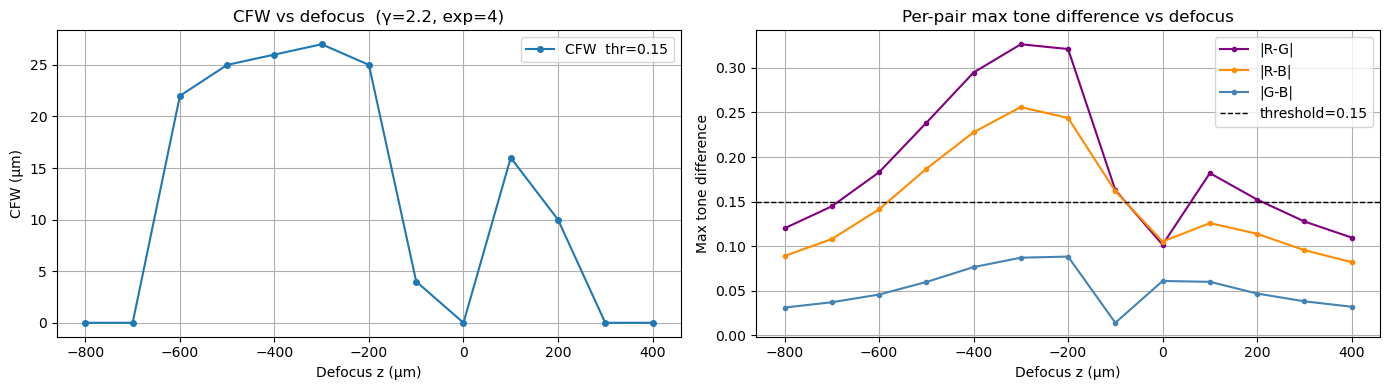

Max CFW: 27 µm  at z = -300 µm


In [54]:
# ── FFTPSF: CFW and per-pair max tone difference vs defocus ──────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(_z_bake, _cfw_curve, "o-", ms=4, label=f"CFW  thr={_THR_FFTPSF}")
ax1.set(title=f"CFW vs defocus  (γ={_GAMMA_BAKE}, exp={_EXPOSURE_BAKE})",
        xlabel="Defocus z (µm)", ylabel="CFW (µm)")
ax1.legend(); ax1.grid(True)

for _pair, _col in [("R-G", "purple"), ("R-B", "darkorange"), ("G-B", "steelblue")]:
    ax2.plot(_z_bake, _pair_diff[_pair], "o-", ms=3, color=_col, label=f"|{_pair}|")
ax2.axhline(_THR_FFTPSF, color="k", ls="--", lw=1, label=f"threshold={_THR_FFTPSF}")
ax2.set(title="Per-pair max tone difference vs defocus",
        xlabel="Defocus z (µm)", ylabel="Max tone difference")
ax2.legend(); ax2.grid(True)

plt.tight_layout(); plt.show()

print(f"Max CFW: {_cfw_curve.max()} µm  at z = {_z_bake[_cfw_curve.argmax()]:+.0f} µm")

       z   R_trans   G_trans   B_trans   max_diff    CFW
------------------------------------------------------------
    -400       144       116       123     0.2948     19
    -350       128       100       107     0.3157     20
    -300       112        84        92     0.3265     22
    -250        96        71        78     0.3284     22
    -200        82        58        64     0.3211     21
    -150        68        48        51     0.2807     14
    -100        56        44        44     0.1629      0
     -50        47        54        48     0.1123      0
       0        48        73        64     0.1052      0
      50        62        92        83     0.1645      0
     100        82       112       102     0.1820      0
     150       102       132       122     0.1686      0
     200       122       153       141     0.1523      0
     250       142       174       161     0.1392      0
     300       162       194       181     0.1277      0
     350       182       21

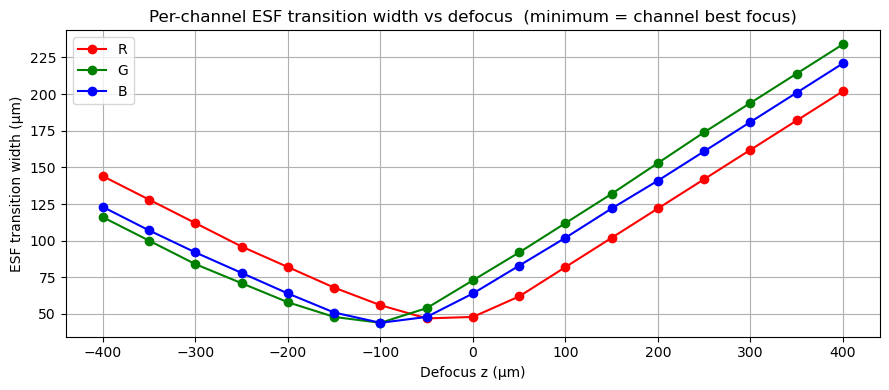

In [47]:
# ── ESF transition width vs defocus ──────────────────────────────────────────
print(f"{'z':>8}  {'R_trans':>8}  {'G_trans':>8}  {'B_trans':>8}  "
      f"{'max_diff':>9}  {'CFW':>5}")
print("-" * 60)
for _i, _z in enumerate(_z_bake):
    print(f"{_z:>8.0f}  "
          f"{_trans_width['R'][_i]:>8}  {_trans_width['G'][_i]:>8}  {_trans_width['B'][_i]:>8}  "
          f"{_max_diff[_i]:>9.4f}  {_cfw_curve[_i]:>5}")
print(f"\nMax diff = {_max_diff.max():.4f} at z = {_z_bake[_max_diff.argmax()]:+.0f} µm  "
      f"(threshold = {_THR_FFTPSF})")

plt.figure(figsize=(9, 4))
for _c, _col in [("R", "r"), ("G", "g"), ("B", "b")]:
    plt.plot(_z_bake, _trans_width[_c], "o-", color=_col, label=_c)
plt.xlabel("Defocus z (µm)")
plt.ylabel("ESF transition width (µm)")
plt.title("Per-channel ESF transition width vs defocus  (minimum = channel best focus)")
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

Label                                            CFW   max_diff   R_tr   G_tr   B_tr
--------------------------------------------------------------------------------
z=-300 / -CFW peak                                22     0.3265    112     84     92
z=-250 / max_diff peak                            22     0.3284     96     71     78
z=-100 / G best focus / B best focus               0     0.1629     56     44     44
z=-50 / R best focus                               0     0.1123     47     54     48
z=0 (nominal)                                      0     0.1052     48     73     64
z=+50 / +CFW peak                                  0     0.1645     62     92     83
[1/6] computing z=-300 µm ...
[2/6] computing z=-250 µm ...


KeyboardInterrupt: 

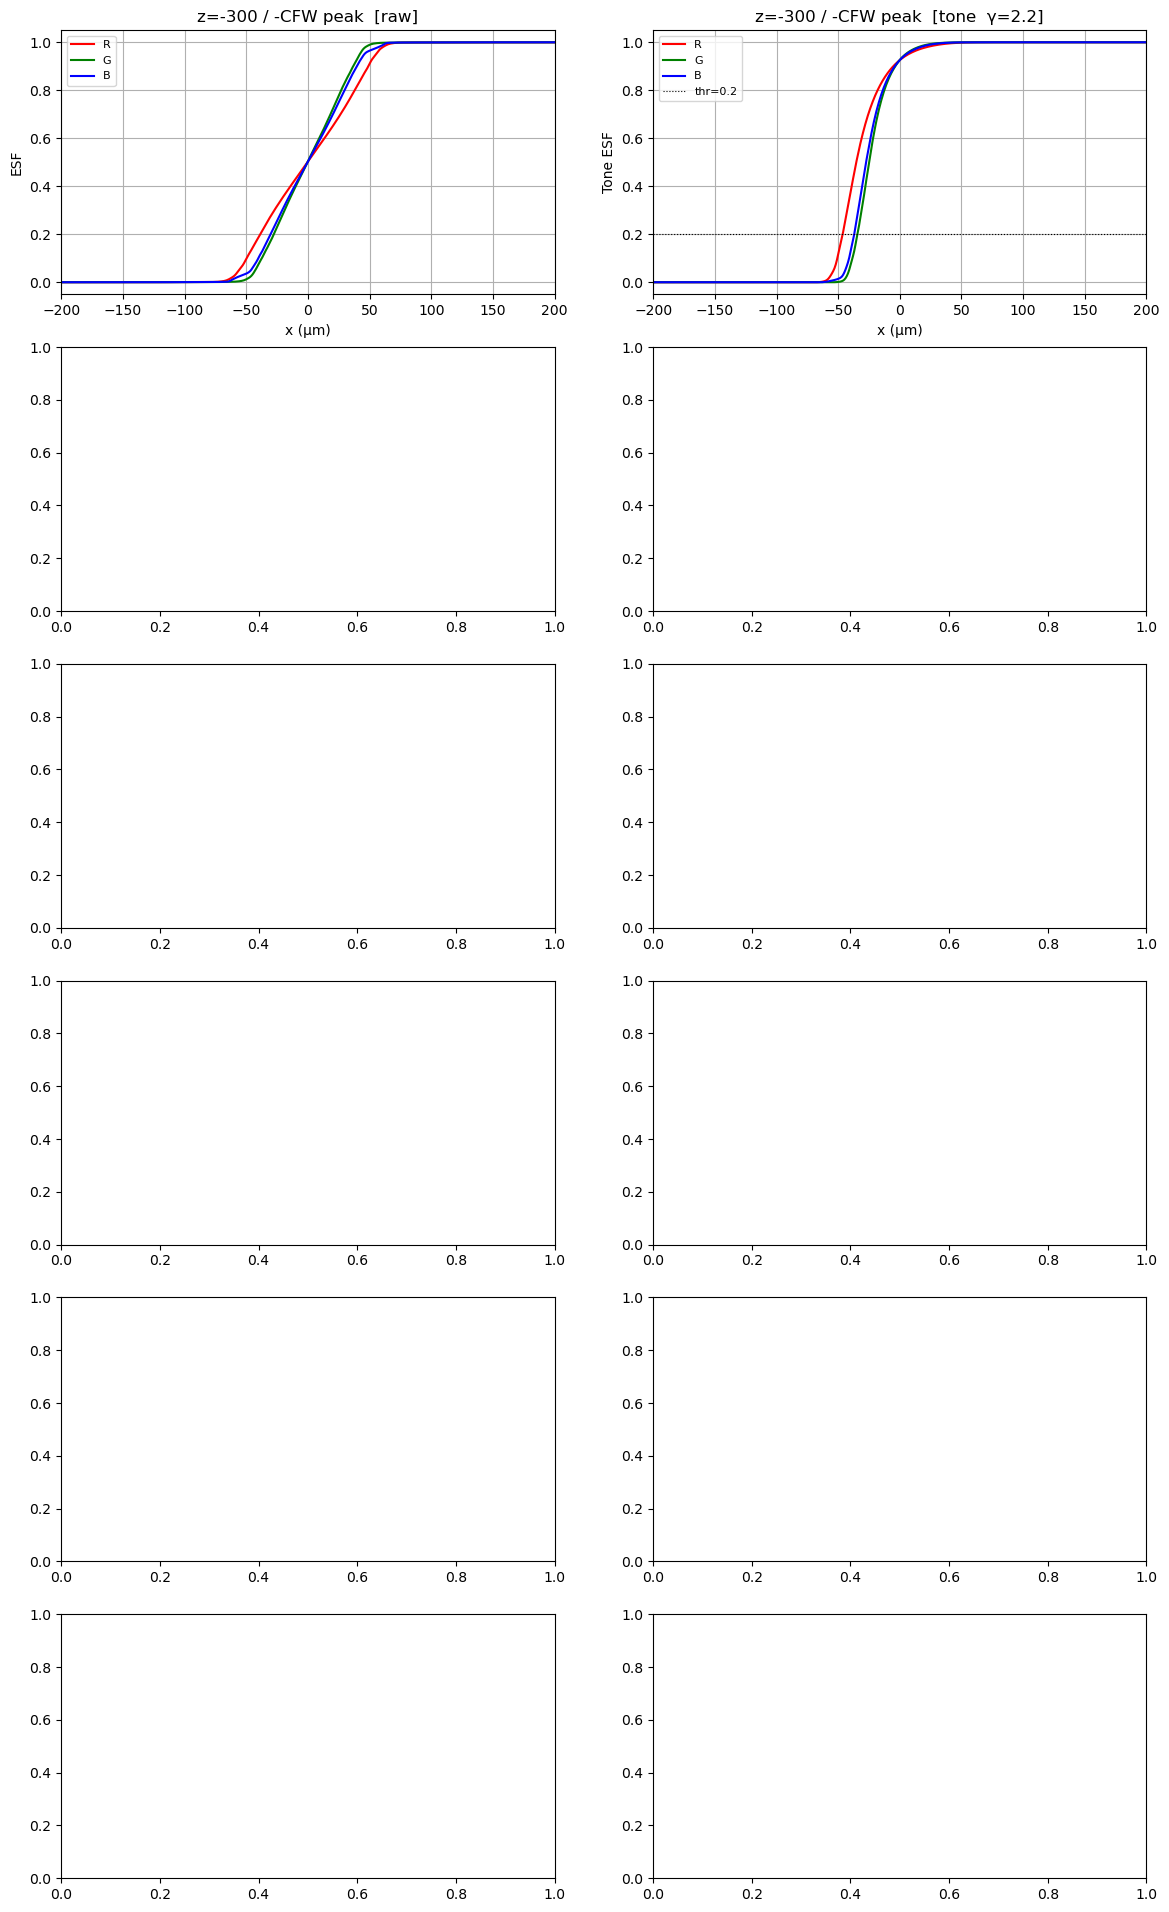

In [48]:
# ── ESF diagnostic: key defocus positions ────────────────────────────────────
# Key z values are selected automatically from bake results:
#   z=0, per-channel best focus (min transition width), ±CFW peaks, max_diff peak.

def _key_z_points() -> list[tuple[float, str]]:
    pts: dict[float, str] = {0.0: "z=0 (nominal)"}
    for _c in ("R", "G", "B"):
        _z = float(_z_bake[_trans_width[_c].argmin()])
        pts[_z] = pts.get(_z, f"z={_z:+.0f}") + f" / {_c} best focus"
    for _mask, _side in [(_z_bake > 0, "+CFW peak"), (_z_bake < 0, "-CFW peak")]:
        if _mask.any():
            _z = float(_z_bake[_mask][_cfw_curve[_mask].argmax()])
            pts[_z] = pts.get(_z, f"z={_z:+.0f}") + f" / {_side}"
    _z = float(_z_bake[_max_diff.argmax()])
    pts[_z] = pts.get(_z, f"z={_z:+.0f}") + " / max_diff peak"
    return sorted(pts.items())

_diag_points = _key_z_points()

print(f"{'Label':45s}  {'CFW':>5}  {'max_diff':>9}  {'R_tr':>5}  {'G_tr':>5}  {'B_tr':>5}")
print("-" * 80)
for _z, _lbl in _diag_points:
    _i = int(np.searchsorted(_z_bake, _z))
    print(f"{_lbl:45s}  {_cfw_curve[_i]:>5}  {_max_diff[_i]:>9.4f}  "
          f"{_trans_width['R'][_i]:>5}  {_trans_width['G'][_i]:>5}  {_trans_width['B'][_i]:>5}")

# Compute ESFs at each key point and plot
_n = len(_diag_points)
fig, _axes = plt.subplots(_n, 2, figsize=(14, 4 * _n), squeeze=False)
_xlim = (-200, 200)

for _row, (_z_val, _lbl) in enumerate(_diag_points):
    print(f"[{_row+1}/{_n}] computing z={_z_val:+.0f} µm ...")
    _raw, _tone_esf = {}, {}
    for _c in ("R", "G", "B"):
        _r = compute_polychromatic_esf(
            lens1, _c, float(_z_val), _X_UM,
            num_rays=_NUM_RAYS, grid_size=_GRID_SIZE,
            wl_stride=_WL_STRIDE, strategy=_STRATEGY,
        )
        _raw[_c] = _r
        _tone_esf[_c] = _tone_map(_r)
        del _r; gc.collect()

    for _c, _col in [("R", "r"), ("G", "g"), ("B", "b")]:
        _axes[_row, 0].plot(_X_UM, _raw[_c],      color=_col, label=_c, lw=1.5)
        _axes[_row, 1].plot(_X_UM, _tone_esf[_c], color=_col, label=_c, lw=1.5)
    _axes[_row, 0].set(title=f"{_lbl}  [raw]",
                       xlabel="x (µm)", ylabel="ESF", xlim=_xlim)
    _axes[_row, 1].set(title=f"{_lbl}  [tone  γ={_GAMMA_BAKE}]",
                       xlabel="x (µm)", ylabel="Tone ESF", xlim=_xlim)
    _axes[_row, 1].axhline(_THR_FFTPSF, color="k", ls=":", lw=0.8,
                           label=f"thr={_THR_FFTPSF}")
    for _ax in _axes[_row]:
        _ax.legend(fontsize=8); _ax.grid(True)

    del _raw, _tone_esf; gc.collect()

plt.tight_layout(); plt.show()